# Source Attestation & Trust Calibration — Analysis Notebook

Analysis pipeline for the 3×2×2 within-subjects vignette study (attestation × correctness × stakes).

Expected columns: `response_id, version, trial_position, stem_id, stakes, att_level, correctness, trust_num, reliance_code, consequence_num, att_code, corr_code, stakes_code`.

Coding convention (from the prep pipeline): `att_code` ∈ {0,1,2} (none/weak/strong, ordinal); `corr_code`, `stakes_code` ∈ {−0.5,+0.5} (contrast-coded).

## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
import matplot2tikz, os
import matplotlib as mpl
import matplotlib.pyplot as plt

# Overleaf-mirrored output tree. Everything the paper \input{}s is written
# under latex/ so the whole folder can be copied straight into Overleaf.
from pathlib import Path
LATEX_DIR   = Path("latex")
FIG_OUT     = LATEX_DIR / "figures"
TAB_OUT     = LATEX_DIR / "tables"
for _d in (LATEX_DIR, FIG_OUT, TAB_OUT):
    _d.mkdir(parents=True, exist_ok=True)
os.makedirs("images", exist_ok=True)         # raster provenance copies

# Force a print-safe (light) style so exported tikz is readable on the
# white IEEE page. Without this, an active dark style bleeds a black
# background + white text into the .tex, which is invisible on paper.
mpl.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'text.color':        'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
})

# Map the notebook's internal figure names to the filenames the paper
# \input{}s from figures/. Reruns overwrite these directly -- no manual
# cleanup step. Names not in the map fall through to their own name.
TIKZ_RENAME = {
    'outcome_means_by_attestation':  'outcome_means',
    'spearman_corr_heatmap':         'correlation_matrix',
    'dist_reliance_action':          'reliance_actions',
    'calibration_gap':               'calibration_gap',
    'sample_composition_ai_baseline':'ai_intake_distributions',
    'attenuation_by_expertise':      'expertise_trust',
    'baseline_trust_vs_state_trust': 'baseline_state_trust',
    'sample_composition_demographics':'demographics',
    'trust_means':                   'trust_means',
}
# dist_reliance_action is referenced twice in the paper; write both names.
TIKZ_ALIASES = {
    'dist_reliance_action': ['reliance_actions', 'trust_reliance_distributions'],
}

def save_tikz(name):
    """Export the current figure as print-safe .tex under the paper's
    filename(s), into latex/figures/."""
    try:
        matplot2tikz.clean_figure()
    except (ValueError, IndexError):
        pass  # cleaning is optional; skip when it chokes on this figure
    # paper-facing copies under mapped name(s)
    targets = TIKZ_ALIASES.get(name, [TIKZ_RENAME.get(name, name)])
    for t in targets:
        matplot2tikz.save(f"{FIG_OUT}/{t}.tex")

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')
pd.set_option('display.max_columns', None)

DATA_DIR = Path('../prepped_data')
DATA_FILE = "long_coded.csv"
DATA_PATH = DATA_DIR / DATA_FILE
assert DATA_PATH.exists(), f'Missing {DATA_PATH}'
IMG_DIR = Path('images')
ATT_ORDER = ['none', 'weak', 'strong']

## 1. Load & validate

In [2]:
df = pd.read_csv(DATA_PATH)

required = ['response_id', 'stem_id', 'stakes', 'att_level', 'correctness',
            'trust_num', 'reliance_code', 'consequence_num',
            'att_code', 'corr_code', 'stakes_code']
missing = [c for c in required if c not in df.columns]
assert not missing, f'Missing required columns: {missing}'

n_part = df['response_id'].nunique()
trials = df.groupby('response_id').size()
print(f'Participants: {n_part}')
print(f'Rows (participant-trials): {len(df)}')
print(f'Trials per participant — min {trials.min()}, median {int(trials.median())}, max {trials.max()}')
print(f'Unique stems: {df.stem_id.nunique()}')
if "version" in df.columns:
    print(f'Versions present: {sorted(df.version.unique())}')

# Coding sanity checks
print('\nCoding check:')
print('  att_code   :', sorted(df.att_code.dropna().unique()), '(expect 0,1,2)')
print('  corr_code  :', sorted(df.corr_code.dropna().unique()), '(expect -0.5,0.5)')
print('  stakes_code:', sorted(df.stakes_code.dropna().unique()), '(expect -0.5,0.5)')
print('  trust_num  :', df.trust_num.min(), 'to', df.trust_num.max(), '(expect 1-7)')
print('  reliance   :', sorted(df.reliance_code.dropna().unique()), '(expect 1,2,3)')
print('  consequence:', df.consequence_num.min(), 'to', df.consequence_num.max(), '(expect 1-5)')

Participants: 94
Rows (participant-trials): 1128
Trials per participant — min 12, median 12, max 12
Unique stems: 12
Versions present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Coding check:
  att_code   : [np.int64(0), np.int64(1), np.int64(2)] (expect 0,1,2)
  corr_code  : [np.float64(-0.5), np.float64(0.5)] (expect -0.5,0.5)
  stakes_code: [np.float64(-0.5), np.float64(0.5)] (expect -0.5,0.5)
  trust_num  : 1 to 7 (expect 1-7)
  reliance   : [np.int64(1), np.int64(2), np.int64(3)] (expect 1,2,3)
  consequence: 1 to 5 (expect 1-5)


In [3]:
# Design balance: cell counts for the full 3x2x2 crossing
cell_counts = (df.groupby(['att_level', 'correctness', 'stakes'])
                 .size().rename('n').reset_index())
cell_pivot = cell_counts.pivot_table(index=['att_level'],
                                     columns=['correctness', 'stakes'],
                                     values='n').reindex(ATT_ORDER)
print('Cell counts (rows = attestation):')
display(cell_pivot)

# Missingness on outcomes
print('\nMissing values on outcomes:')
print(df[['trust_num', 'reliance_code', 'consequence_num']].isna().sum())

Cell counts (rows = attestation):


correctness correct         incorrect        
stakes         high     low      high     low
att_level                                    
none        94.0000 94.0000   94.0000 94.0000
weak        94.0000 94.0000   94.0000 94.0000
strong      94.0000 94.0000   94.0000 94.0000


Missing values on outcomes:
trust_num          0
reliance_code      0
consequence_num    0
dtype: int64


## 2. Descriptives by condition

In [4]:
def desc_by(col, by):
    g = df.groupby(by)[col].agg(['mean', 'std', 'count'])
    if by == 'att_level':
        g = g.reindex(ATT_ORDER)
    return g

print('=== TRUST (1-7) ===')
print('\nby attestation:'); display(desc_by('trust_num', 'att_level'))
print('by correctness:'); display(desc_by('trust_num', 'correctness'))
print('by stakes:'); display(desc_by('trust_num', 'stakes'))

print('\nTrust: attestation x correctness (means):')
display(df.pivot_table('trust_num', 'att_level', 'correctness', 'mean').reindex(ATT_ORDER))

=== TRUST (1-7) ===

by attestation:


,mean,std,count
att_level,,,
none,3.8856,1.7065,376
weak,4.3138,1.5535,376
strong,4.7420,1.6248,376


by correctness:


,mean,std,count
correctness,,,
correct,4.3918,1.6616,564
incorrect,4.2358,1.6665,564


by stakes:


,mean,std,count
stakes,,,
high,4.1117,1.6582,564
low,4.5160,1.6490,564



Trust: attestation x correctness (means):


correctness,correct,incorrect
att_level,,
none,4.0372,3.7340
weak,4.2766,4.3511
strong,4.8617,4.6223


In [5]:
print('=== RELIANCE (1=Reject, 2=Verify, 3=Use) ===')
print('by attestation:'); display(desc_by('reliance_code', 'att_level'))
print('by correctness:'); display(desc_by('reliance_code', 'correctness'))
print('by stakes:'); display(desc_by('reliance_code', 'stakes'))

print('\n=== PERCEIVED CONSEQUENCE (1-5) ===')
print('by stakes (manipulation check):'); display(desc_by('consequence_num', 'stakes'))
print('by attestation:'); display(desc_by('consequence_num', 'att_level'))

=== RELIANCE (1=Reject, 2=Verify, 3=Use) ===
by attestation:


,mean,std,count
att_level,,,
none,2.0346,0.5717,376
weak,2.1144,0.4955,376
strong,2.2447,0.5099,376


by correctness:


,mean,std,count
correctness,,,
correct,2.1454,0.5059,564
incorrect,2.1170,0.5596,564


by stakes:


,mean,std,count
stakes,,,
high,2.0071,0.4693,564
low,2.2553,0.5642,564



=== PERCEIVED CONSEQUENCE (1-5) ===
by stakes (manipulation check):


,mean,std,count
stakes,,,
high,3.9628,0.9777,564
low,2.5000,1.1972,564


by attestation:


,mean,std,count
att_level,,,
none,3.2048,1.3616,376
weak,3.3005,1.2681,376
strong,3.1888,1.3141,376


## 3. Mixed models — crossed random effects (participant + stem)

- **H1**: positive `att_code` slope on trust and reliance.
- **H2**: `att_code` effect persists controlling for `corr_code`; small/null `corr_code` effect = trust tracks the label, not truth.
- **H4**: `stakes_code` effect, and the attestation×stakes / correctness×stakes interactions.

In [6]:
def fit_crossed(dv, data, extra_fixed=''):
    """Crossed RE: random intercept for participant + variance component for stem."""
    formula = f'{dv} ~ att_code + corr_code + stakes_code' + extra_fixed
    md = smf.mixedlm(formula, data, groups=data['response_id'],
                     re_formula='~1',
                     vc_formula={'stem': '0 + C(stem_id)'})
    return md.fit(reml=False)

print('============ TRUST — main-effects model ============')
m_trust = fit_crossed('trust_num', df)
print(m_trust.summary())

============ TRUST — main-effects model ============
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: trust_num 
No. Observations: 1128    Method:             ML        
No. Groups:       94      Scale:              0.8713    
Min. group size:  12      Log-Likelihood:     -2007.9121
Max. group size:  12      Converged:          Yes       
Mean group size:  12.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      3.886    0.114 34.228 0.000  3.663  4.108
att_code       0.428    0.048  8.862 0.000  0.333  0.523
corr_code      0.156    0.079  1.978 0.048  0.001  0.311
stakes_code   -0.404    0.079 -5.124 0.000 -0.559 -0.250
Group Var      0.846                                    
stem Var       0.884                                    



In [7]:
print('============ RELIANCE — main-effects model ============')
print('(Reliance is ordinal 1-3; this LMM treats it as continuous for a fast read.')
print(' See Section 3b for the ordinal model.)')
m_rel = fit_crossed('reliance_code', df)
print(m_rel.summary())

print('\n============ PERCEIVED CONSEQUENCE — manipulation check ============')
m_cons = fit_crossed('consequence_num', df)
print(m_cons.summary())

============ RELIANCE — main-effects model ============
(Reliance is ordinal 1-3; this LMM treats it as continuous for a fast read.
 See Section 3b for the ordinal model.)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reliance_code
No. Observations: 1128    Method:             ML           
No. Groups:       94      Scale:              0.0934       
Min. group size:  12      Log-Likelihood:     -829.2561    
Max. group size:  12      Converged:          Yes          
Mean group size:  12.0                                     
------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     2.026     0.028  73.443  0.000   1.972   2.080
att_code      0.105     0.018   5.885  0.000   0.070   0.140
corr_code     0.028     0.029   0.973  0.330  -0.029   0.086
stakes_code  -0.248     0.029  -8.516  0.000  -0.305 

### 3a. H4 — interaction & stakes moderation

In [8]:
print('=== Trust: attestation x correctness (H4 core interaction) ===')
m_int = fit_crossed('trust_num', df, extra_fixed=' + att_code:corr_code')
print(m_int.summary().tables[1])

print('\n=== Trust: full stakes moderation (att x corr x stakes) ===')
m_full = smf.mixedlm('trust_num ~ att_code * corr_code * stakes_code',
                     df, groups=df['response_id'], re_formula='~1',
                     vc_formula={'stem': '0 + C(stem_id)'}).fit(reml=False)
print(m_full.summary().tables[1])

=== Trust: attestation x correctness (H4 core interaction) ===
                     Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept            3.886    0.114  34.229  0.000   3.663   4.108
att_code             0.428    0.048   8.863  0.000   0.333   0.523
corr_code            0.188    0.125   1.507  0.132  -0.057   0.432
stakes_code         -0.404    0.079  -5.124  0.000  -0.559  -0.250
att_code:corr_code  -0.032    0.097  -0.330  0.741  -0.221   0.157
Group Var            0.846                                        
stem Var             0.884                                        

=== Trust: full stakes moderation (att x corr x stakes) ===
                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                        3.886    0.113  34.274  0.000   3.663   4.108
att_code                         0.428    0.048   8.926  0.000   0.334   0.522
corr_code                        0.188    0.124   1.517  0.129  -0.055   0.431
att_code:corr_code      

### 3b. Reliance as ordinal (robustness)

In [9]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

ord_df = df.dropna(subset=['reliance_code', 'att_code', 'corr_code', 'stakes_code']).copy()
ord_df['reliance_ord'] = ord_df['reliance_code'].astype(int)

om = OrderedModel(ord_df['reliance_ord'],
                  ord_df[['att_code', 'corr_code', 'stakes_code']],
                  distr='logit')
om_res = om.fit(method='bfgs', disp=False)
print('=== Ordinal logit (no RE) — reliance ===')
print(om_res.summary())

# GEE clustered by participant (population-averaged, accounts for within-person dependence)
print('\n=== GEE (clustered by participant) — reliance ===')
gee = smf.gee('reliance_code ~ att_code + corr_code + stakes_code',
              groups='response_id', data=ord_df,
              cov_struct=sm.cov_struct.Exchangeable()).fit()
print(gee.summary().tables[1])

=== Ordinal logit (no RE) — reliance ===
                             OrderedModel Results                             
Dep. Variable:           reliance_ord   Log-Likelihood:                -844.71
Model:                   OrderedModel   AIC:                             1699.
Method:            Maximum Likelihood   BIC:                             1725.
Date:                Sat, 18 Jul 2026                                         
Time:                        23:22:13                                         
No. Observations:                1128                                         
Df Residuals:                    1123                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
att_code        0.4376      0.082      5.364      0.000       0.278       0.597
corr_cod

## 4. H3 — mediation scaffold (attestation/correctness → trust → reliance)

In [10]:
# Path a: effect of att/corr on the mediator (trust) — already in m_trust
print('PATH a (predictors -> trust):')
print(m_trust.summary().tables[1].loc[['att_code', 'corr_code']])

# Path b & c': mediator + predictors -> reliance
print('\nPATH b/c\' (trust + predictors -> reliance):')
m_med = smf.mixedlm('reliance_code ~ trust_num + att_code + corr_code + stakes_code',
                    df, groups=df['response_id'], re_formula='~1',
                    vc_formula={'stem': '0 + C(stem_id)'}).fit(reml=False)
print(m_med.summary().tables[1])

print('\n# To complete H3: compute indirect effect (a*b) with a bootstrap CI,')
print('# or use a multilevel mediation framework. This cell only exposes the paths.')

PATH a (predictors -> trust):
           Coef. Std.Err.      z  P>|z| [0.025 0.975]
att_code   0.428    0.048  8.862  0.000  0.333  0.523
corr_code  0.156    0.079  1.978  0.048  0.001  0.311

PATH b/c' (trust + predictors -> reliance):
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept     1.258    0.039  32.642  0.000   1.183   1.334
trust_num     0.198    0.008  24.285  0.000   0.182   0.214
att_code      0.020    0.015   1.371  0.170  -0.009   0.050
corr_code    -0.002    0.024  -0.104  0.917  -0.049   0.044
stakes_code  -0.168    0.024  -7.039  0.000  -0.215  -0.121
Group Var     0.013                                        
stem Var      0.098                                        

# To complete H3: compute indirect effect (a*b) with a bootstrap CI,
# or use a multilevel mediation framework. This cell only exposes the paths.


## 5. Tidy results export

In [11]:
def tidy(res, label):
    """Pull the coefficient table from a fitted mixedlm result into a tidy frame."""
    p = pd.DataFrame({
        'term': res.params.index,
        'coef': res.params.values,
        'std_err': res.bse.reindex(res.params.index).values,
        'z': res.tvalues.reindex(res.params.index).values,
        'p_value': res.pvalues.reindex(res.params.index).values,
    })
    p.insert(0, 'model', label)
    return p

results = pd.concat([
    tidy(m_trust, 'trust_main'),
    tidy(m_rel,   'reliance_main_LMM'),
    tidy(m_cons,  'consequence_main'),
    tidy(m_int,   'trust_attXcorr'),
], ignore_index=True)

display(results)
results.to_csv('analysis_results.csv', index=False)
print('Wrote analysis_results.csv')

,model,term,coef,std_err,z,p_value
0,trust_main,Intercept,3.8856,0.1135,34.2284,0.0000
1,trust_main,att_code,0.4282,0.0483,8.8623,0.0000
2,trust_main,corr_code,0.1560,0.0789,1.9776,0.0480
3,trust_main,stakes_code,-0.4043,0.0789,-5.1237,0.0000
4,trust_main,Group Var,0.9706,NaN,NaN,NaN
5,trust_main,stem Var,1.0148,NaN,NaN,NaN
6,reliance_main_LMM,Intercept,2.0262,0.0276,73.4431,0.0000
7,reliance_main_LMM,att_code,0.1051,0.0179,5.8852,0.0000
8,reliance_main_LMM,corr_code,0.0284,0.0291,0.9732,0.3304
9,reliance_main_LMM,stakes_code,-0.2482,0.0291,-8.5156,0.0000


Wrote analysis_results.csv


## 7. Publication-grade pgfplots figures (bold, native TikZ)

Emits clean hand-styled `pgfplots` `.tex` straight from `df`, replacing the matplot2tikz exports for the results figures. Re-running regenerates every figure from the current sample, so the paper always matches the analysis. The paper preamble must `\input{figures/_figstyle_auto.tex}` (written by this cell).

## 6. Quick diagnostic plots

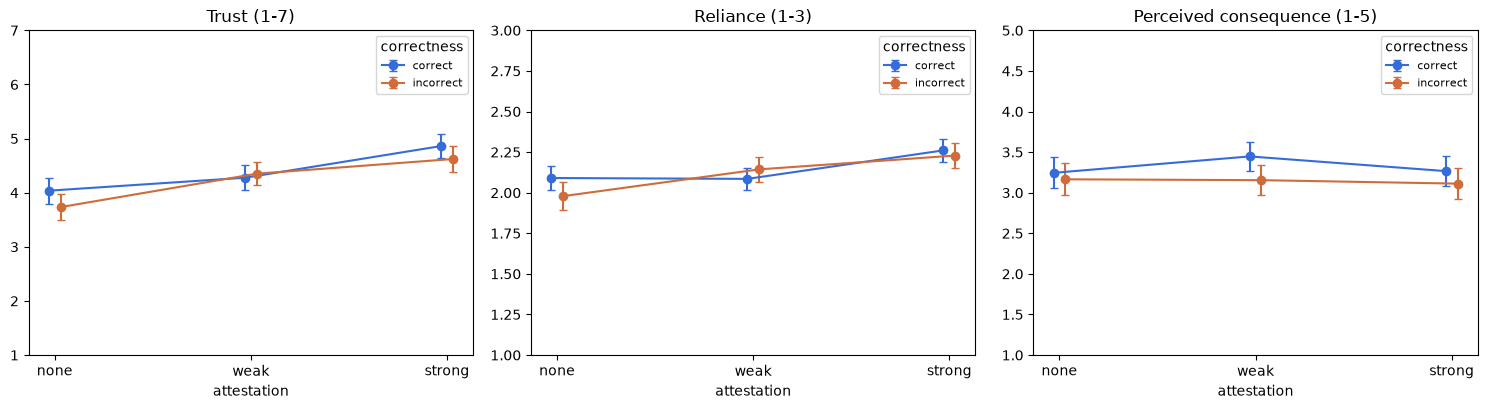

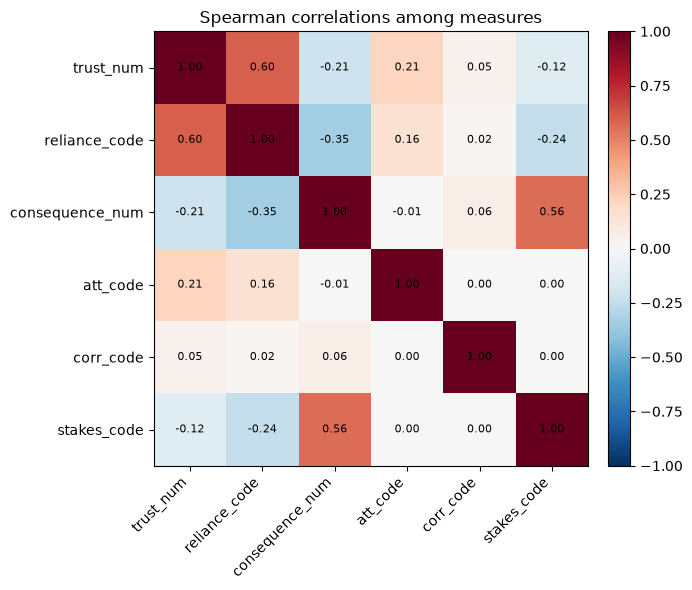

Note: att/corr/stakes are coded predictors, so their mutual
correlations are ~0 by design (balanced factorial).


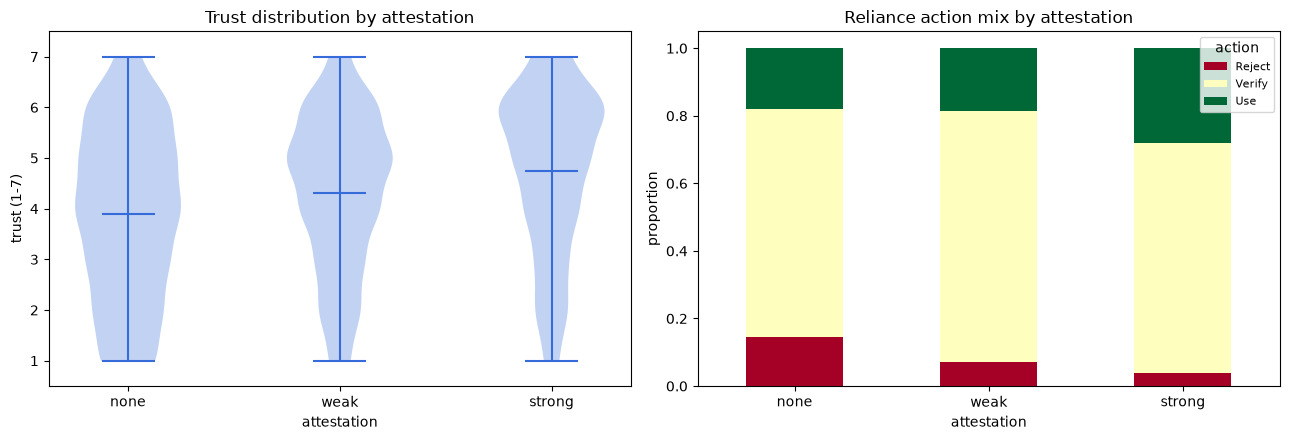

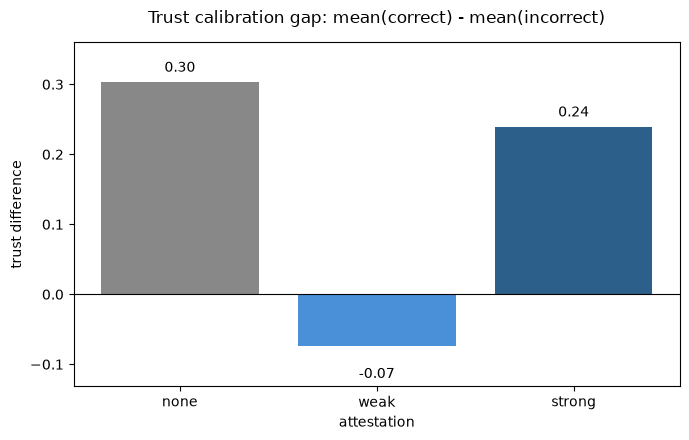

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def _ci95(s):
    s = s.dropna()
    if len(s) < 2:
        return np.nan
    return 1.96 * s.std(ddof=1) / np.sqrt(len(s))

# --- Figure 1: outcome means by attestation x correctness, with 95% CIs ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [('trust_num', 'Trust (1-7)', (1, 7)),
          ('reliance_code', 'Reliance (1-3)', (1, 3)),
          ('consequence_num', 'Perceived consequence (1-5)', (1, 5))]
for ax, (dv, lab, ylim) in zip(axes, panels):
    m = df.pivot_table(dv, 'att_level', 'correctness', 'mean').reindex(ATT_ORDER)
    e = df.pivot_table(dv, 'att_level', 'correctness', _ci95).reindex(ATT_ORDER)
    x = np.arange(len(ATT_ORDER))
    for j, col in enumerate(m.columns):
        ax.errorbar(x + (j - 0.5) * 0.06, m[col], yerr=e[col],
                    marker='o', capsize=3, label=col)
    ax.set_xticks(x); ax.set_xticklabels(ATT_ORDER)
    ax.set_title(lab); ax.set_xlabel('attestation'); ax.set_ylim(ylim)
    ax.legend(title='correctness', fontsize=8)
# [removed for tikz] fig.suptitle('Outcome means by attestation x correctness (95% CI)', y=1.02)
plt.tight_layout()
fig_name = 'outcome_means_by_attestation'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
# save_tikz('outcome_means_by_attestation')  # REPLACED by pgfplots emitter (section 9)
plt.show()

# --- Figure 2: Spearman correlation heatmap of numeric measures ---
num = ['trust_num', 'reliance_code', 'consequence_num',
       'att_code', 'corr_code', 'stakes_code']
corr = df[num].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha='right')
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='black', fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Spearman correlations among measures')
plt.tight_layout()
fig_name = 'spearman_corr_heatmap'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
# Heatmap ships as a raster PNG, not tikz: matplot2tikz emits a
# degenerate externalized image + underscore-laden nodes that break
# IEEE compilation. A correlation heatmap gains nothing from vector.
import shutil
    # [removed] raster correlation_matrix.png copy -- replaced by
    # the vector latex/figures/correlation_matrix.tex from the emitter.
plt.show()
print('Note: att/corr/stakes are coded predictors, so their mutual')
print('correlations are ~0 by design (balanced factorial).')

# --- Figure 3: trust distribution + reliance action mix by attestation ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

data = [df[df.att_level == a].trust_num.dropna().values for a in ATT_ORDER]
axes[0].violinplot(data, showmeans=True)
axes[0].set_xticks([1, 2, 3]); axes[0].set_xticklabels(ATT_ORDER)
axes[0].set_title('Trust distribution by attestation')
axes[0].set_ylabel('trust (1-7)'); axes[0].set_ylim(0.5, 7.5)
axes[0].set_xlabel('attestation')

prop = (df.groupby('att_level')['reliance_code']
          .value_counts(normalize=True).unstack().reindex(ATT_ORDER))
prop.columns = ['Reject', 'Verify', 'Use'][:prop.shape[1]]
prop.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Reliance action mix by attestation')
axes[1].set_ylabel('proportion'); axes[1].set_xlabel('attestation')
axes[1].legend(title='action', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
fig_name = 'dist_reliance_action'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
# save_tikz('dist_reliance_action')  # REPLACED by pgfplots emitter (section 9)
plt.show()

# --- Figure 4: trust calibration gap = mean(correct) - mean(incorrect) ---
# A large positive gap = trust discriminates correct from incorrect (good
# calibration). A gap near zero = trust does NOT track truth at that
# attestation level (the miscalibration the study is about).
fig, ax = plt.subplots(figsize=(7, 4.5))
gap = df.pivot_table('trust_num', 'att_level', 'correctness', 'mean').reindex(ATT_ORDER)
diff = gap['correct'] - gap['incorrect']
ax.bar(ATT_ORDER, diff, color=['#888888', '#4a90d9', '#2c5f8a'])
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Trust calibration gap: mean(correct) - mean(incorrect)', pad=14)
ax.set_ylabel('trust difference'); ax.set_xlabel('attestation')
ax.margins(y=0.15)
for i, v in enumerate(diff):
    ax.text(i, v + (0.01 if v >= 0 else -0.03), f'{v:.2f}',
            ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout()
fig_name = 'calibration_gap'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
# save_tikz('calibration_gap')  # REPLACED by pgfplots emitter (section 9)
plt.show()

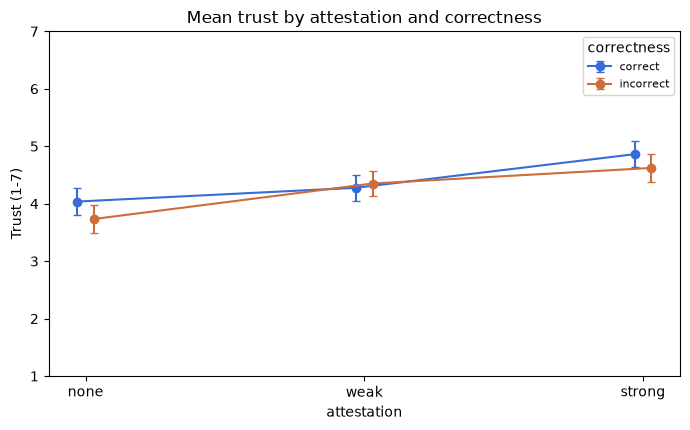

In [13]:
# --- H1 figure: mean trust by attestation x correctness (trust_means) ---
# Standalone trust panel for the H1 result in the body. Uses the same
# 95% CI helper and print-safe style; exported via save_tikz to
# figures/trust_means.tex.
fig, ax = plt.subplots(figsize=(7, 4.4))
m = df.pivot_table('trust_num', 'att_level', 'correctness', 'mean').reindex(ATT_ORDER)
e = df.pivot_table('trust_num', 'att_level', 'correctness', _ci95).reindex(ATT_ORDER)
x = np.arange(len(ATT_ORDER))
for j, col in enumerate(m.columns):
    ax.errorbar(x + (j - 0.5) * 0.06, m[col], yerr=e[col],
                marker='o', capsize=3, label=col)
ax.set_xticks(x); ax.set_xticklabels(ATT_ORDER)
ax.set_title('Mean trust by attestation and correctness')
ax.set_xlabel('attestation'); ax.set_ylabel('Trust (1-7)'); ax.set_ylim(1, 7)
ax.legend(title='correctness', fontsize=8)
plt.tight_layout()
fig_name = 'trust_means'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
# save_tikz('trust_means')  # REPLACED by pgfplots emitter (section 9)
plt.show()

## 8. Intake & demographic figures

These require the per-participant intake columns produced by the updated `reconstruct_data.py` (`ai_expertise_num`, `baseline_trust_num`, `ai_frequency_num`, `age`, `gender`). If those columns aren't present, the cell prints a note and skips. **Expertise/baseline relationships are exploratory and underpowered at pilot N; demographics are for sample characterization only.**

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Map text intake scales to ordered ints if only the text versions are present.
_EXP = {'Novice':1,'Basic User':2,'Experienced User':3,'Advanced Practitioner':4,'Expert/Specialist':5}
_BT  = {'Strongly Distrust':1,'Distrust':2,'Neither Trust nor Distrust':3,'Trust':4,'Strongly Trust':5}
_FQ  = {'Never':0,'Monthly':1,'Weekly':2,'Daily':3}
if 'ai_expertise' in df.columns and 'ai_expertise_num' not in df.columns:
    df['ai_expertise_num'] = df['ai_expertise'].map(_EXP)
if 'baseline_trust' in df.columns and 'baseline_trust_num' not in df.columns:
    df['baseline_trust_num'] = df['baseline_trust'].map(_BT)
if 'ai_frequency' in df.columns and 'ai_frequency_num' not in df.columns:
    df['ai_frequency_num'] = df['ai_frequency'].map(_FQ)

HAS_INTAKE = any(c in df.columns for c in ['ai_expertise_num','baseline_trust_num'])
if not HAS_INTAKE:
    print('Intake columns not found. Run the updated reconstruct_data.py to merge')
    print('demographics, then re-load df. Skipping Section 8 figures.')
else:
    per_p = df.drop_duplicates('response_id').copy()
    print('Intake columns present; per-participant n =', len(per_p))

Intake columns present; per-participant n = 94


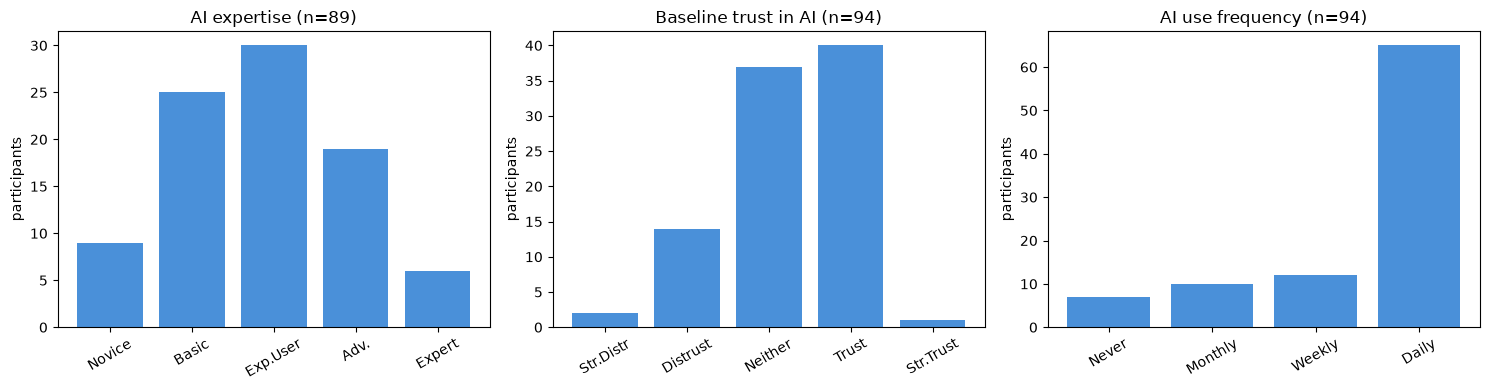

In [15]:
# --- Figure 5: AI-baseline individual differences (sample composition) ---
if HAS_INTAKE:
    specs = [('ai_expertise_num', 'AI expertise', {1:'Novice',2:'Basic',3:'Exp.User',4:'Adv.',5:'Expert'}),
             ('baseline_trust_num', 'Baseline trust in AI', {1:'Str.Distr',2:'Distrust',3:'Neither',4:'Trust',5:'Str.Trust'}),
             ('ai_frequency_num', 'AI use frequency', {0:'Never',1:'Monthly',2:'Weekly',3:'Daily'})]
    specs = [s for s in specs if s[0] in per_p.columns and per_p[s[0]].notna().any()]
    if specs:
        fig, axes = plt.subplots(1, len(specs), figsize=(5*len(specs), 4), squeeze=False)
        for ax, (col, lab, labels) in zip(axes[0], specs):
            vc = per_p[col].dropna().astype(int).value_counts().sort_index()
            ax.bar([labels.get(i, i) for i in vc.index], vc.values, color='#4a90d9')
            ax.set_title(f'{lab} (n={int(per_p[col].notna().sum())})')
            ax.set_ylabel('participants'); ax.tick_params(axis='x', rotation=30)
        # [removed for tikz] fig.suptitle('Sample composition: AI-baseline individual differences', y=1.03)
        plt.tight_layout()
        fig_name = 'sample_composition_ai_baseline'
        plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
        save_tikz(fig_name)
        plt.show()

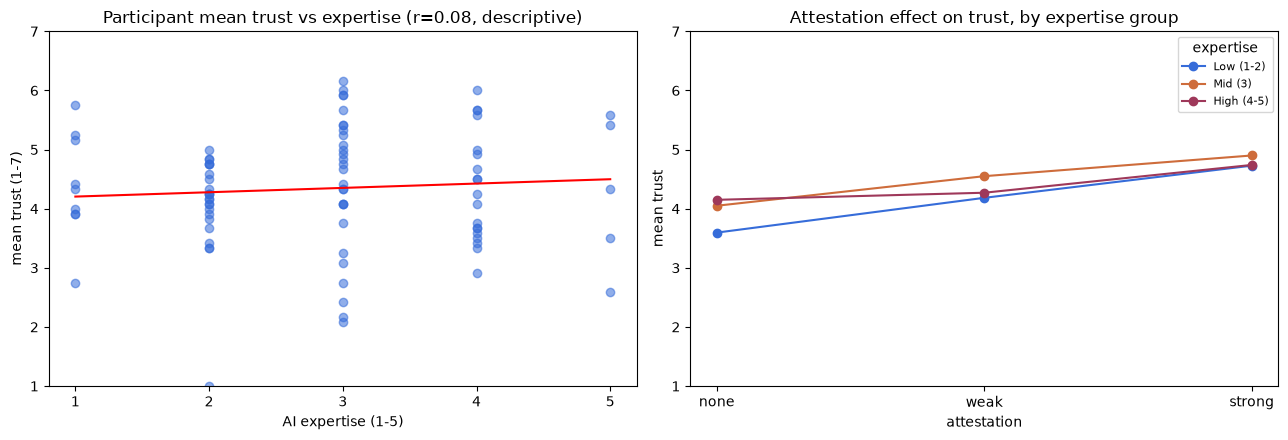

Right panel is descriptive; the att x expertise interaction test is in
the expertise model (Section 0-4 script / covariate models), and it is
underpowered at pilot N. Do not read a slope difference here as a finding.


In [16]:
# --- Figure 6: expertise vs trust, and attestation slope by expertise group ---
if HAS_INTAKE and 'ai_expertise_num' in df.columns and df['ai_expertise_num'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    pp = (df.dropna(subset=['ai_expertise_num'])
            .groupby('response_id')
            .agg(mt=('trust_num', 'mean'), exp=('ai_expertise_num', 'first')))
    axes[0].scatter(pp.exp, pp.mt, alpha=0.55)
    if pp.exp.nunique() > 1:
        b, a = np.polyfit(pp.exp, pp.mt, 1)
        xs = np.linspace(pp.exp.min(), pp.exp.max(), 50)
        axes[0].plot(xs, a + b*xs, 'r-', lw=1.5)
        r = pp.exp.corr(pp.mt)
        axes[0].set_title(f'Participant mean trust vs expertise (r={r:.2f}, descriptive)')
    axes[0].set_xlabel('AI expertise (1-5)'); axes[0].set_ylabel('mean trust (1-7)')
    axes[0].set_xticks([1,2,3,4,5]); axes[0].set_ylim(1, 7)

    d = df.dropna(subset=['ai_expertise_num']).copy()
    d['exp_grp'] = pd.cut(d.ai_expertise_num, [0,2,3,5], labels=['Low (1-2)','Mid (3)','High (4-5)'])
    for g in ['Low (1-2)','Mid (3)','High (4-5)']:
        m = d[d.exp_grp==g].groupby('att_level')['trust_num'].mean().reindex(ATT_ORDER)
        axes[1].plot(range(3), m.values, marker='o', label=g)
    axes[1].set_xticks(range(3)); axes[1].set_xticklabels(ATT_ORDER)
    axes[1].set_title('Attestation effect on trust, by expertise group')
    axes[1].set_xlabel('attestation'); axes[1].set_ylabel('mean trust'); axes[1].set_ylim(1, 7)
    axes[1].legend(title='expertise', fontsize=8)
    plt.tight_layout()
    fig_name = 'attenuation_by_expertise'
    plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
    save_tikz(fig_name)
    plt.show()
    print('Right panel is descriptive; the att x expertise interaction test is in')
    print('the expertise model (Section 0-4 script / covariate models), and it is')
    print('underpowered at pilot N. Do not read a slope difference here as a finding.')

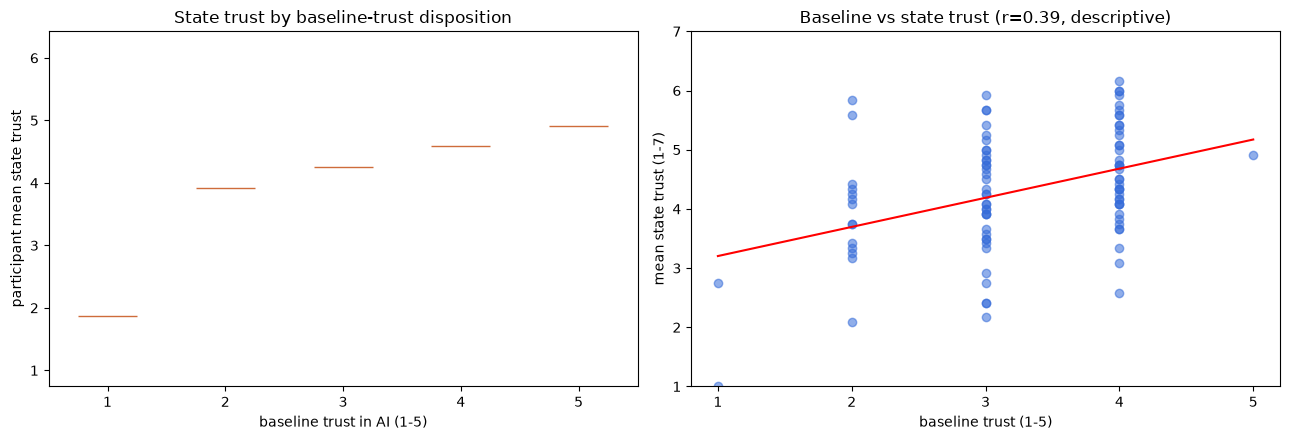

In [17]:
# --- Figure 7: baseline trust disposition vs state trust ---
if HAS_INTAKE and 'baseline_trust_num' in df.columns and df['baseline_trust_num'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    pp2 = (df.dropna(subset=['baseline_trust_num'])
             .groupby('response_id')
             .agg(mt=('trust_num', 'mean'), bt=('baseline_trust_num', 'first')))
    levels = sorted(pp2.bt.unique())
    axes[0].boxplot([pp2[pp2.bt==L].mt.values for L in levels],
                    tick_labels=[int(L) for L in levels])
    axes[0].set_title('State trust by baseline-trust disposition')
    axes[0].set_xlabel('baseline trust in AI (1-5)')
    axes[0].set_ylabel('participant mean state trust')

    axes[1].scatter(pp2.bt, pp2.mt, alpha=0.55)
    if pp2.bt.nunique() > 1:
        b, a = np.polyfit(pp2.bt, pp2.mt, 1)
        xs = np.linspace(pp2.bt.min(), pp2.bt.max(), 50)
        axes[1].plot(xs, a + b*xs, 'r-', lw=1.5)
        r = pp2.bt.corr(pp2.mt)
        axes[1].set_title(f'Baseline vs state trust (r={r:.2f}, descriptive)')
    axes[1].set_xlabel('baseline trust (1-5)'); axes[1].set_ylabel('mean state trust (1-7)')
    axes[1].set_xticks([1,2,3,4,5]); axes[1].set_ylim(1, 7)
    plt.tight_layout()
    fig_name = 'baseline_trust_vs_state_trust'
    plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
    save_tikz(fig_name)
    plt.show()

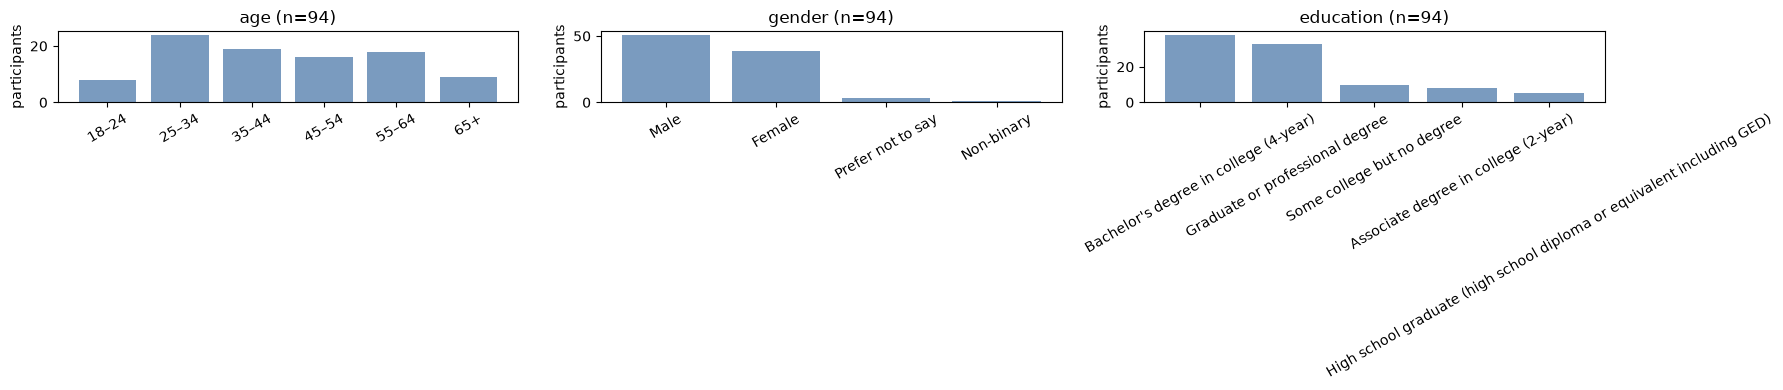

In [18]:
# --- Figure 8: demographic composition (characterization only) ---
if HAS_INTAKE:
    demo = [('age', ['18–24','25–34','35–44','45–54','55–64','65+']),
            ('gender', None),
            ('education', None)]
    demo = [(c, o) for c, o in demo if c in per_p.columns and per_p[c].notna().any()]
    if demo:
        fig, axes = plt.subplots(1, len(demo), figsize=(6*len(demo), 4), squeeze=False)
        for ax, (col, order) in zip(axes[0], demo):
            vc = per_p[col].value_counts()
            if order:
                vc = vc.reindex([o for o in order if o in vc.index])
            ax.bar(vc.index.astype(str), vc.values, color='#7a9bbf')
            ax.set_title(f'{col} (n={int(per_p[col].notna().sum())})')
            ax.set_ylabel('participants'); ax.tick_params(axis='x', rotation=30)
        # [removed for tikz] fig.suptitle('Sample composition: demographics (characterization only)', y=1.03)
        plt.tight_layout()
        fig_name = 'sample_composition_demographics'
        plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
        save_tikz(fig_name)
        plt.show()

In [19]:
# ============================================================================
# Publication figures — matched to the tier-stratified provenance paper style
# (three-tone palette, chunky rounded cards, Stealth arrows, left-edge accent
# bars). Emits clean pgfplots .tex from df into latex/figures/. Re-run to
# regenerate from the current sample. Requires \input{figures/_figstyle_auto.tex}
# in the paper preamble (written here).
# ============================================================================
import numpy as np
FIGDIR = FIG_OUT  # latex/figures from setup cell
_ATT = ['none', 'weak', 'strong']

def _se(s):
    s = s.dropna()
    return s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else float('nan')
def _cell(dv, a, co):
    return df[(df.att_level == a) & (df.correctness == co)][dv]
def _marg(dv, a):
    return df[df.att_level == a][dv]
def _f(v, p=2):
    return f'{v:.{p}f}'

# ---- shared style: provenance-paper palette (verbatim) + pgfplots base ------
_STYLE = r"""% AUTO-GENERATED. Style matched to the tier-stratified provenance paper:
% three-tone palette (fill/line/dark text), chunky rounded cards, Stealth arrows.
\definecolor{boxgray}{HTML}{8A887E}
\definecolor{boxgrayfill}{HTML}{C4C0AF}
\definecolor{boxgraytext}{HTML}{1C1C1A}
\definecolor{boxblue}{HTML}{0073AE}
\definecolor{boxbluefill}{HTML}{7CC0EE}
\definecolor{boxbluetext}{HTML}{06315C}
\definecolor{llmfill}{HTML}{FFC64D}
\definecolor{llmline}{HTML}{B36A00}
\definecolor{llmtext}{HTML}{5A3608}
\definecolor{ragfill}{HTML}{7FD4B8}
\definecolor{ragline}{HTML}{0B7D5E}
\definecolor{ragtext}{HTML}{0A3A2C}
\definecolor{planefill}{HTML}{D5E6F9}
\definecolor{lensline}{HTML}{3B7DC4}
\colorlet{attPrimary}{boxblue}
\colorlet{attAccent}{llmline}
\colorlet{attPositive}{ragline}
\colorlet{attInk}{boxgraytext}
\colorlet{attMuted}{boxgray}
\pgfplotsset{
  attbase/.style={
    axis line style={boxgraytext, line width=1.0pt},
    tick style={boxgraytext, line width=0.8pt},
    tick align=outside, tick pos=left,
    label style={boxgraytext, font=\small},
    tick label style={boxgraytext, font=\footnotesize},
    title style={boxbluetext, font=\bfseries\small},
    every axis plot/.append style={line width=1.6pt},
    grid=major, grid style={boxgray!45, dotted, line width=0.5pt},
    legend cell align={left},
    legend style={draw=boxgray, line width=0.8pt, fill=white,
      rounded corners=3pt, font=\footnotesize},
    >={Stealth[length=2.6mm,width=2mm]},
  },
}
\usetikzlibrary{positioning,arrows.meta,calc,fit,backgrounds}
"""
(FIGDIR / '_figstyle_auto.tex').write_text(_STYLE)

def _emit_trust_means():
    rc = "\n".join(f"  {i} {_f(_cell('trust_num',a,'correct').mean(),3)} {_f(_se(_cell('trust_num',a,'correct')),3)} {_f(_cell('trust_num',a,'correct').mean())}" for i,a in enumerate(_ATT))
    ri = "\n".join(f"  {i} {_f(_cell('trust_num',a,'incorrect').mean(),3)} {_f(_se(_cell('trust_num',a,'incorrect')),3)} {_f(_cell('trust_num',a,'incorrect').mean())}" for i,a in enumerate(_ATT))
    tex = r"""% AUTO-GENERATED. Mean trust by attestation x correctness (+/- 1 SE).
\begin{tikzpicture}
\begin{axis}[
  attbase, width=\columnwidth, height=5.6cm,
  title={Mean trust by attestation and correctness},
  xlabel={Attestation strength}, ylabel={Trust (1--7)},
  xmin=-0.35, xmax=2.35, xtick={0,1,2}, xticklabels={None,Weak,Strong},
  ymin=3, ymax=5.4, ytick={3,3.5,4,4.5,5},
  nodes near coords, point meta=explicit symbolic,
  every node near coord/.append style={font=\footnotesize\bfseries, anchor=south, yshift=3pt},
  legend style={at={(0.02,0.98)}, anchor=north west},
]
\addplot+[boxblue, mark=*, mark size=3pt, mark options={fill=boxbluefill, draw=boxblue, line width=1pt},
  error bars/.cd, y dir=both, y explicit, error bar style={boxblue, line width=1pt}]
  table[x=x,y=y,y error=err,meta=lbl]{
  x y err lbl
%%RC%%
  };
\addlegendentry{Correct}
\addplot+[llmline, mark=square*, mark size=3pt, mark options={fill=llmfill, draw=llmline, line width=1pt},
  error bars/.cd, y dir=both, y explicit, error bar style={llmline, line width=1pt}]
  table[x=x,y=y,y error=err,meta=lbl]{
  x y err lbl
%%RI%%
  };
\addlegendentry{Incorrect}
\end{axis}
\end{tikzpicture}
""".replace("%%RC%%", rc).replace("%%RI%%", ri)
    (FIGDIR / 'trust_means.tex').write_text(tex)

def _emit_calibration_gap():
    gaps = [_cell('trust_num',a,'correct').mean() - _cell('trust_num',a,'incorrect').mean() for a in _ATT]
    # three-tone: blue for positive gaps, amber for negative (semantic: amber=miscalibrated)
    bars = ""
    for i,g in enumerate(gaps):
        fill, line = ('boxbluefill','boxblue') if g >= 0 else ('llmfill','llmline')
        bars += f"\\draw[draw={line}, fill={fill}, line width=1.3pt, rounded corners=1.5pt] (axis cs:{i-0.4},0) rectangle (axis cs:{i+0.4},{g:.4f});\n"
    labels = ""
    for i,g in enumerate(gaps):
        anchor = 'south' if g >= 0 else 'north'
        yoff = g + (0.014 if g >= 0 else -0.014)
        labels += f"\\node[font=\\footnotesize\\bfseries, text=boxgraytext, anchor={anchor}] at (axis cs:{i},{yoff:.4f}) {{{g:+.2f}}};\n"
    ymin = min(min(gaps) - 0.08, -0.15); ymax = max(gaps) + 0.10
    tex = r"""% AUTO-GENERATED. Trust calibration gap = mean(correct) - mean(incorrect).
\begin{tikzpicture}
\begin{axis}[
  attbase, width=\columnwidth, height=5.6cm,
  title={Trust calibration gap: mean(correct) $-$ mean(incorrect)},
  xlabel={Attestation strength}, ylabel={Trust difference},
  xmin=-0.6, xmax=2.6, xtick={0,1,2}, xticklabels={None,Weak,Strong},
  ymin=%%YMIN%%, ymax=%%YMAX%%, axis on top,
]
%%BARS%%\draw[boxgraytext, line width=1.0pt] (axis cs:-0.6,0) -- (axis cs:2.6,0);
%%LABELS%%\end{axis}
\end{tikzpicture}
""".replace("%%BARS%%", bars).replace("%%LABELS%%", labels).replace("%%YMIN%%", f"{ymin:.3f}").replace("%%YMAX%%", f"{ymax:.3f}")
    (FIGDIR / 'calibration_gap.tex').write_text(tex)

def _emit_reliance_actions():
    p1 = "\n".join(f"  {i} {_f(_marg('trust_num',a).mean(),3)} {_f(_se(_marg('trust_num',a)),3)} {_f(_marg('trust_num',a).mean())}" for i,a in enumerate(_ATT))
    props = {a:{k:(_marg('reliance_code',a)==v).mean() for k,v in [('rej',1),('ver',2),('use',3)]} for a in _ATT}
    mk = lambda key: " ".join(f"({i},{props[a][key]:.3f})[.{round(props[a][key]*100):02d}]" for i,a in enumerate(_ATT))
    tex = r"""% AUTO-GENERATED. Left: marginal mean trust by attestation (+/-1 SE).
% Right: reliance action mix (Reject/Verify/Use) by attestation.
\begin{tikzpicture}
\begin{groupplot}[group style={horizontal sep=1.9cm, group size=2 by 1},
  attbase, width=0.46\linewidth, height=5.4cm,
  xtick={0,1,2}, xticklabels={None,Weak,Strong}, xlabel={Attestation strength}]
\nextgroupplot[title={Mean trust by attestation}, ylabel={Trust (1--7)},
  ymin=3, ymax=5.2, xmin=-0.35, xmax=2.35,
  nodes near coords, point meta=explicit symbolic,
  every node near coord/.append style={font=\scriptsize\bfseries, anchor=south, yshift=2pt}]
\addplot+[boxblue, mark=*, mark size=2.6pt, mark options={fill=boxbluefill, draw=boxblue, line width=0.8pt},
  error bars/.cd, y dir=both, y explicit, error bar style={boxblue, line width=1pt}]
  table[x=x,y=y,y error=err,meta=lbl]{
  x y err lbl
%%P1%%
  };
\nextgroupplot[title={Reliance action mix}, ylabel={Proportion},
  ymin=0, ymax=1.06, xmin=-0.5, xmax=2.5, ybar stacked, bar width=19pt,
  legend style={at={(0.5,-0.30)}, anchor=north, legend columns=-1,
    /tikz/every even column/.append style={column sep=0.35cm}},
  nodes near coords, point meta=explicit symbolic,
  every node near coord/.append style={font=\tiny\bfseries, anchor=center, text=white}]
\addplot+[draw=llmline, fill=llmfill, line width=1pt] coordinates {%%REJ%%};
\addlegendentry{Reject}
\addplot+[draw=boxblue, fill=boxbluefill, line width=1pt] coordinates {%%VER%%};
\addlegendentry{Verify}
\addplot+[draw=ragline, fill=ragfill, line width=1pt] coordinates {%%USE%%};
\addlegendentry{Use}
\end{groupplot}
\end{tikzpicture}
""".replace("%%P1%%", p1).replace("%%REJ%%", mk('rej')).replace("%%VER%%", mk('ver')).replace("%%USE%%", mk('use'))
    (FIGDIR / 'reliance_actions.tex').write_text(tex)
    (FIGDIR / 'trust_reliance_distributions.tex').write_text(tex)

def _emit_outcome_means():
    panels = [('trust_num','Trust (1--7)',1,7,'{1,...,7}'),
              ('reliance_code','Reliance (1--3)',1,3,'{1,1.5,2,2.5,3}'),
              ('consequence_num','Perceived consequence (1--5)',1,5,'{1,2,3,4,5}')]
    blocks = ""
    for k,(dv,lab,lo,hi,yt) in enumerate(panels):
        rc = "\n".join(f"  {i} {_f(_cell(dv,a,'correct').mean(),3)} {_f(_se(_cell(dv,a,'correct')),3)} {_f(_cell(dv,a,'correct').mean())}" for i,a in enumerate(_ATT))
        ri = "\n".join(f"  {i} {_f(_cell(dv,a,'incorrect').mean(),3)} {_f(_se(_cell(dv,a,'incorrect')),3)} {_f(_cell(dv,a,'incorrect').mean())}" for i,a in enumerate(_ATT))
        leg = "\\addlegendentry{Correct}" if k==0 else ""
        leg2 = "\\addlegendentry{Incorrect}" if k==0 else ""
        blocks += (r"""\nextgroupplot[ylabel={%%LAB%%}, ymin=%%LO%%, ymax=%%HI%%, ytick=%%YT%%]
\addplot+[boxblue, mark=*, mark size=2.2pt, mark options={fill=boxbluefill, draw=boxblue, line width=0.7pt},
  error bars/.cd, y dir=both, y explicit, error bar style={boxblue, line width=0.9pt}]
  table[x=x,y=y,y error=err,meta=lbl]{
  x y err lbl
%%RC%%
  };
%%LEG%%
\addplot+[llmline, mark=square*, mark size=2.2pt, mark options={fill=llmfill, draw=llmline, line width=0.7pt},
  error bars/.cd, y dir=both, y explicit, error bar style={llmline, line width=0.9pt}]
  table[x=x,y=y,y error=err,meta=lbl]{
  x y err lbl
%%RI%%
  };
%%LEG2%%
""".replace("%%LAB%%",lab).replace("%%LO%%",str(lo)).replace("%%HI%%",str(hi)).replace("%%YT%%",yt).replace("%%RC%%",rc).replace("%%RI%%",ri).replace("%%LEG%%",leg).replace("%%LEG2%%",leg2))
    tex = r"""% AUTO-GENERATED. Outcome means by attestation x correctness (+/- 1 SE).
\begin{tikzpicture}
\begin{groupplot}[group style={horizontal sep=1.5cm, group size=3 by 1},
  attbase, width=0.38\linewidth, height=5.2cm,
  xmin=-0.35, xmax=2.35, xtick={0,1,2}, xticklabels={None,Weak,Strong},
  xlabel={Attestation strength},
  nodes near coords, point meta=explicit symbolic,
  every node near coord/.append style={font=\tiny, anchor=south, yshift=1pt},
  legend style={at={(0.5,1.16)}, anchor=north, legend columns=-1}]
%%BLOCKS%%\end{groupplot}
\end{tikzpicture}
""".replace("%%BLOCKS%%", blocks)
    (FIGDIR / 'outcome_means.tex').write_text(tex)

def _emit_mediation():
    import statsmodels.formula.api as smf
    vc = {'stem': '0 + C(stem_id)'}
    a = smf.mixedlm('trust_num ~ att_code + corr_code + stakes_code', df, groups=df['response_id'], vc_formula=vc, re_formula='1').fit(reml=False, method='lbfgs').params['att_code']
    mb = smf.mixedlm('reliance_code ~ trust_num + att_code + corr_code + stakes_code', df, groups=df['response_id'], vc_formula=vc, re_formula='1').fit(reml=False, method='lbfgs')
    b = mb.params['trust_num']; cp = mb.params['att_code']
    tex = r"""% AUTO-GENERATED. Mediation path diagram, provenance-paper card style.
% Indirect a*b = %%IND%%.
\begin{tikzpicture}[
  >={Stealth[length=3mm,width=2.2mm]}, font=\small,
  card/.style={rectangle, rounded corners=6pt, align=center,
    inner xsep=9pt, inner ysep=8pt, line width=1.4pt, text width=24mm, minimum height=15mm},
  attnode/.style={card, draw=boxblue, fill=boxbluefill, text=boxbluetext},
  mednode/.style={card, draw=llmline, fill=llmfill, text=llmtext},
  outnode/.style={card, draw=ragline, fill=ragfill, text=ragtext},
  flow/.style={->, draw=boxblue, line width=1.5pt},
  weak/.style={->, draw=boxgray, line width=1.2pt, dash pattern=on 4pt off 3pt},
  elab/.style={font=\footnotesize\bfseries, text=boxbluetext, fill=white,
    inner xsep=3pt, inner ysep=1.5pt, rounded corners=2pt},
  graylab/.style={font=\footnotesize, text=boxgraytext, fill=white,
    inner xsep=3pt, inner ysep=1.5pt, rounded corners=2pt},
]
\node[attnode] (att) {\textbf{Source}\\\textbf{Attestation}};
\node[mednode, right=22mm of att] (trust) {\textbf{State}\\\textbf{Trust}};
\node[outnode, right=22mm of trust] (rel) {\textbf{Behavioral}\\\textbf{Reliance}};
\fill[boxblue] ($(att.north west)+(4pt,-7pt)$) rectangle ($(att.south west)+(6pt,7pt)$);
\fill[llmline] ($(trust.north west)+(4pt,-7pt)$) rectangle ($(trust.south west)+(6pt,7pt)$);
\fill[ragline] ($(rel.north west)+(4pt,-7pt)$) rectangle ($(rel.south west)+(6pt,7pt)$);
\draw[flow] (att) -- node[elab]{$a=%%A%%$} (trust);
\draw[flow] (trust) -- node[elab]{$b=%%B%%$} (rel);
\draw[weak, bend right=38] (att.south) to node[graylab, below]{$c'=%%CP%%$ (n.s.)} (rel.south);
\end{tikzpicture}
""".replace("%%A%%", _f(a,3)).replace("%%B%%", _f(b,3)).replace("%%CP%%", _f(cp,3)).replace("%%IND%%", _f(a*b,3))
    (FIGDIR / 'mediation.tex').write_text(tex)

def _emit_correlation():
    num = ['trust_num','reliance_code','consequence_num','att_code','corr_code','stakes_code']
    corr = df[num].corr(method='spearman')
    rows = "".join(f"{xi} {yi} {corr.iloc[yi,xi]:.2f}\n" for yi in range(6) for xi in range(6))
    tex = r"""% AUTO-GENERATED. Spearman correlation heatmap, provenance blue ramp.
\begin{tikzpicture}
\begin{axis}[
  width=8.6cm, height=8.6cm, axis line style={draw=none}, tick style={draw=none},
  enlargelimits=false,
  colormap={provdiv}{color(-1cm)=(llmline); color(0cm)=(white); color(1cm)=(boxblue)},
  point meta min=-1, point meta max=1, colorbar,
  colorbar style={width=0.32cm, ytick={-1,-0.5,0,0.5,1},
    tick label style={font=\footnotesize}, tick style={draw=none}, axis line style={draw=none}},
  xtick={0,1,2,3,4,5}, ytick={0,1,2,3,4,5},
  xticklabels={trust, reliance, conseq., attest., correct., stakes},
  yticklabels={trust, reliance, conseq., attest., correct., stakes},
  xticklabel style={rotate=45, anchor=north east, font=\footnotesize},
  yticklabel style={font=\footnotesize}, y dir=reverse,
  title style={font=\bfseries\small, text=boxbluetext}, title={Spearman correlations among measures},
  nodes near coords={\pgfmathprintnumber[fixed, precision=2]{\pgfplotspointmeta}},
  nodes near coords style={font=\footnotesize\bfseries, text=boxgraytext, anchor=center}]
\addplot[matrix plot*, point meta=explicit, mesh/cols=6, mesh/rows=6]
table[meta=C]{
x y C
%%ROWS%%};
\end{axis}
\end{tikzpicture}
""".replace("%%ROWS%%", rows)
    (FIGDIR / 'correlation_matrix.tex').write_text(tex)

_emit_trust_means()
_emit_calibration_gap()
_emit_reliance_actions()
_emit_outcome_means()
_emit_mediation()
_emit_correlation()
print("Wrote provenance-styled pgfplots figures to", FIGDIR)


# ---- table emitter: results coefficients (H1-H4) into latex/tables/ --------
def _emit_results_table():
    """Emit a compact H1-H4 results table to latex/tables/results_summary.tex,
    computed from the current sample so it always matches the analysis."""
    import statsmodels.formula.api as smf
    vc = {'stem': '0 + C(stem_id)'}
    def fit(dv, formula_rhs):
        return smf.mixedlm(f'{dv} ~ {formula_rhs}', df, groups=df['response_id'],
                           vc_formula=vc, re_formula='1').fit(reml=False, method='lbfgs')
    mt  = fit('trust_num',    'att_code + corr_code + stakes_code')
    mtx = fit('trust_num',    'att_code*corr_code + stakes_code')
    mr  = fit('reliance_code','att_code + corr_code + stakes_code')
    def row(label, res, term):
        b, se, z, p = res.params[term], res.bse[term], res.tvalues[term], res.pvalues[term]
        pstr = '$<$.001' if p < .001 else f'{p:.3f}'.lstrip('0')
        return f"{label} & {b:+.3f} & {se:.3f} & {z:+.2f} & {pstr} \\\\"
    rows = "\n".join([
        row("Attestation (trust)",        mt,  'att_code'),
        row("Correctness (trust)",        mt,  'corr_code'),
        row("Stakes (trust)",             mt,  'stakes_code'),
        row("Attestation $\\times$ Correctness (trust)", mtx, 'att_code:corr_code'),
        row("Attestation (reliance)",     mr,  'att_code'),
        row("Stakes (reliance)",          mr,  'stakes_code'),
    ])
    tex = r"""% AUTO-GENERATED results-coefficient summary (mixed-effects models).
\begin{table}[t]
\caption{Fixed-effect estimates from the primary mixed-effects models
(crossed random effects: participant and stem). Attestation coded 0/1/2;
correctness and stakes centered $\pm0.5$.}
\label{tab:results}
\centering
\small
\begin{tabular}{@{}lrrrr@{}}
\toprule
\textbf{Effect} & \textbf{$b$} & \textbf{SE} & \textbf{$z$} & \textbf{$p$} \\
\midrule
%%ROWS%%
\bottomrule
\end{tabular}
\end{table}
""".replace("%%ROWS%%", rows)
    (TAB_OUT / 'results_summary.tex').write_text(tex)
    print(f"  wrote {TAB_OUT}/results_summary.tex")

_emit_results_table()
print("Tables written to latex/tables/.")


Wrote provenance-styled pgfplots figures to latex/figures
  wrote latex/tables/results_summary.tex
Tables written to latex/tables/.
